# AlphaEarth-Only Baseline
**Input:** AlphaEarth embeddings (64ch, 256×256) — native resolution, no upsample needed.

**Output:** 4-band prediction — build%, veg%, water%, nDSM height.

**Scoring weights:** mIoU_build×0.25 + mIoU_trees×0.15 + mIoU_water×0.15 + RMSE_H_build×0.25 + RMSE_H_veg×0.20

**Expected advantage over current model (TerraMind-only, score=0.1241):**
native 256×256 → sharper building boundaries → better IoU_build (currently 0.053).

In [ ]:
# ── 0. Mount Drive ───────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

Mounted at /content/drive


In [ ]:
# ── 1. Imports & config ──────────────────────────────────────────────────────
import re, random, warnings, shutil
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import rasterio
warnings.filterwarnings('ignore', category=rasterio.errors.NotGeoreferencedWarning)

# ── Paths (Drive) ─────────────────────────────────────────────────────────────
DRIVE_ROOT = Path('/content/drive/MyDrive/ESA_Challenge')
AE_TRAIN   = DRIVE_ROOT / 'train' / 'alphaearth_emb'
LABEL_DIR  = DRIVE_ROOT / 'train' / 'labels'
AE_TEST    = DRIVE_ROOT / 'test'  / 'alphaearth_emb'
NORM_STATS = DRIVE_ROOT / 'norm_stats.npy'
CKPT_PATH  = DRIVE_ROOT / 'best_model_ae_only.pth'

# ── Hyperparams ───────────────────────────────────────────────────────────────
BATCH_SIZE = 16
EPOCHS     = 60
LR         = 3e-4
VAL_FRAC   = 0.15
SEED       = 42
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print('Device:', DEVICE)
print('AE train files:', len(sorted(AE_TRAIN.glob('*.tif'))))

# ── Keep-alive: prevents Colab disconnecting when tab is idle ─────────────────
from IPython.display import display, Javascript
display(Javascript("""
setInterval(() => {
  document.querySelectorAll('colab-toolbar-button#connect').forEach(b => b.click());
}, 60000);
console.log('Keep-alive active');
"""))

Device: cuda
AE train files: 2024


<IPython.core.display.Javascript object>

In [ ]:
# ── 2. Copy train data to local SSD (avoids Drive I/O crashes) ───────────────
# Run once per session — skips already-copied files.
from google.colab import drive as _drive

LOCAL_AE  = Path('/content/train_ae')
LOCAL_LBL = Path('/content/train_labels')
LOCAL_AE.mkdir(exist_ok=True)
LOCAL_LBL.mkdir(exist_ok=True)

def safe_copy(src: Path, dst: Path):
    try:
        shutil.copy2(src, dst)
    except OSError:
        _drive.mount('/content/drive', force_remount=True)
        shutil.copy2(src, dst)

print('Copying AE train → SSD…')
for p in sorted(AE_TRAIN.glob('*.tif')):
    dst = LOCAL_AE / p.name
    if not dst.exists():
        safe_copy(p, dst)

print('Copying labels → SSD…')
for p in sorted(LABEL_DIR.glob('*.tif')):
    dst = LOCAL_LBL / p.name
    if not dst.exists():
        safe_copy(p, dst)

# Override paths to use local SSD from here on
AE_TRAIN  = LOCAL_AE
LABEL_DIR = LOCAL_LBL
print(f'Done. AE={len(sorted(LOCAL_AE.glob("*.tif")))}  Labels={len(sorted(LOCAL_LBL.glob("*.tif")))}')

Copying AE train → SSD…
Mounted at /content/drive
Copying labels → SSD…
Done. AE=2024  Labels=2024


In [ ]:
# ── 2b. Pre-normalize AE embeddings → float16 .npy on SSD (run once) ─────────
# After this, __getitem__ loads .npy instead of .tif — ~8x faster I/O.

LOCAL_AE_NPY = Path('/content/train_ae_npy')
LOCAL_AE_NPY.mkdir(exist_ok=True)

stats_tmp = np.load(NORM_STATS, allow_pickle=True).item()
_mean = stats_tmp['alphaearth_emb']['mean'].reshape(-1,1,1).astype(np.float32)
_std  = stats_tmp['alphaearth_emb']['std'].reshape(-1,1,1).astype(np.float32)

tif_files = sorted(LOCAL_AE.glob('*.tif'))
npy_missing = [f for f in tif_files if not (LOCAL_AE_NPY / (f.stem + '.npy')).exists()]
print(f'Pre-normalizing {len(npy_missing)} files to float16 .npy…')

for p in npy_missing:
    with rasterio.open(p) as src:
        arr = src.read().astype(np.float32)            # (64, H, W)
    if arr.shape[-1] != 256 or arr.shape[-2] != 256:
        t = torch.from_numpy(arr).unsqueeze(0)
        t = F.interpolate(t, size=(256,256), mode='bilinear', align_corners=False)
        arr = t.squeeze(0).numpy()
    arr = (arr - _mean) / (_std + 1e-6)
    arr = np.nan_to_num(arr, nan=0.0).astype(np.float16)
    np.save(LOCAL_AE_NPY / (p.stem + '.npy'), arr)

print(f'Done. {len(sorted(LOCAL_AE_NPY.glob("*.npy")))} .npy files ready.')

Pre-normalizing 2024 files to float16 .npy…
Done. 2024 .npy files ready.


In [ ]:
# ── 3. Norm stats ────────────────────────────────────────────────────────────
stats = np.load(NORM_STATS, allow_pickle=True).item()
assert 'alphaearth_emb' in stats, 'Run norm_stats cell in download notebook first!'

AE_MEAN = stats['alphaearth_emb']['mean'].reshape(-1, 1, 1).astype(np.float32)
AE_STD  = stats['alphaearth_emb']['std'].reshape(-1, 1, 1).astype(np.float32)
print(f'Norm stats loaded: {AE_MEAN.shape[0]} channels')

Norm stats loaded: 64 channels


In [ ]:
# ── 4. Dataset ───────────────────────────────────────────────────────────────
def patch_id(stem: str):
    m = re.search(r'_(\d{4})_', stem)
    return m.group(1) if m else None

def load_tif(path: Path, target_hw=256) -> np.ndarray:
    with rasterio.open(path) as src:
        arr = src.read().astype(np.float32)
    if arr.shape[-1] != target_hw or arr.shape[-2] != target_hw:
        t = torch.from_numpy(arr).unsqueeze(0)
        t = F.interpolate(t, size=(target_hw, target_hw), mode='bilinear', align_corners=False)
        arr = t.squeeze(0).numpy()
    return arr

class AEDataset(Dataset):
    def __init__(self, ae_files, label_files, augment=False):
        self.ae_files    = ae_files
        self.label_files = label_files
        self.augment     = augment

    def __len__(self):
        return len(self.ae_files)

    def __getitem__(self, idx):
        try:
            ae  = np.load(self.ae_files[idx]).astype(np.float32)  # already normed float16→32
            lbl = load_tif(self.label_files[idx])                  # (4, 256, 256)
        except Exception:
            ae  = np.zeros((64, 256, 256), dtype=np.float32)
            lbl = np.zeros((4,  256, 256), dtype=np.float32)

        seg    = lbl[:3].clip(0, 1)                   # build, veg, water [0,1]
        height = np.log1p(lbl[3:4].clip(0, None))     # log1p(metres)

        ae     = torch.from_numpy(ae)
        seg    = torch.from_numpy(seg)
        height = torch.from_numpy(height)

        if self.augment:
            if random.random() > 0.5:
                ae = torch.flip(ae, [-1]); seg = torch.flip(seg, [-1]); height = torch.flip(height, [-1])
            if random.random() > 0.5:
                ae = torch.flip(ae, [-2]); seg = torch.flip(seg, [-2]); height = torch.flip(height, [-2])

        return ae, seg, height

# ── Build matched file lists ──────────────────────────────────────────────────
ae_map  = {patch_id(p.stem): p for p in LOCAL_AE_NPY.glob('*.npy') if patch_id(p.stem)}
lbl_map = {patch_id(p.stem): p for p in LABEL_DIR.glob('*.tif') if patch_id(p.stem)}
common  = sorted(ae_map.keys() & lbl_map.keys())
print(f'Matched patches: {len(common)}')

random.shuffle(common)
n_val   = int(len(common) * VAL_FRAC)
val_ids = common[:n_val]
trn_ids = common[n_val:]

trn_ds = AEDataset([ae_map[i] for i in trn_ids], [lbl_map[i] for i in trn_ids], augment=True)
val_ds = AEDataset([ae_map[i] for i in val_ids], [lbl_map[i] for i in val_ids], augment=False)

trn_loader = DataLoader(trn_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
print(f'Train: {len(trn_ds)}  Val: {len(val_ds)}')

Matched patches: 2024
Train: 1721  Val: 303


In [ ]:
# ── 5. Model ──────────────────────────────────────────────────────────────────
class ConvBnRelu(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, p=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, k, padding=p, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.block(x)

class AlphaEarthHead(nn.Module):
    """
    Input : (B, 64, 256, 256)
    Output: seg_logits (B, 3, 256, 256)  — raw logits, NO sigmoid (AMP-safe)
            height     (B, 1, 256, 256)  — softplus >= 0, log1p space
    """
    def __init__(self, in_ch=64):
        super().__init__()
        self.encoder = nn.Sequential(
            ConvBnRelu(in_ch, 128),
            ConvBnRelu(128, 128),
            ConvBnRelu(128,  64),
            ConvBnRelu(64,   64),
        )
        self.seg_head    = nn.Conv2d(64, 3, 1)  # logits — sigmoid only at loss/metrics
        self.height_head = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        feat   = self.encoder(x)
        seg    = self.seg_head(feat)
        height = F.softplus(self.height_head(feat))
        return seg, height

model = AlphaEarthHead(in_ch=64).to(DEVICE)
model = torch.compile(model)   # ~30% faster after 1st epoch warmup (~90s compile cost)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parameters: {n_params:,}')

Parameters: 332,804


In [ ]:
# ── 6. Loss & metrics ─────────────────────────────────────────────────────────
def seg_loss(logits, target):
    """Weighted BCEWithLogitsLoss — AMP-safe. Building ×2."""
    w   = torch.tensor([2.0, 1.0, 1.0], device=logits.device).view(1, 3, 1, 1)
    bce = F.binary_cross_entropy_with_logits(logits, target, reduction='none')
    return (bce * w).mean()

def height_loss(pred, target):
    return F.huber_loss(pred, target, delta=1.0)

def total_loss(logits, height, seg_t, height_t, lam=1.5):
    return seg_loss(logits, seg_t) + lam * height_loss(height, height_t)

@torch.no_grad()
def compute_miou(logits, target, thresh=0.5):
    p     = (torch.sigmoid(logits) > thresh).float()
    t     = (target > thresh).float()
    inter = (p * t).sum(dim=(0, 2, 3))
    union = (p + t - p * t).sum(dim=(0, 2, 3))
    iou   = inter / (union + 1e-6)
    return iou.mean().item(), iou[0].item(), iou[1].item(), iou[2].item()

@torch.no_grad()
def compute_rmse(pred, target):
    p = torch.expm1(pred).clamp(0)
    t = torch.expm1(target).clamp(0)
    return torch.sqrt(F.mse_loss(p, t)).item()

print('Loss & metrics defined.')

Loss & metrics defined.


In [ ]:
# ── 7. Training loop ──────────────────────────────────────────────────────────
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=LR/20)
scaler    = torch.amp.GradScaler('cuda')

best_val_loss = float('inf')
history = []

for epoch in range(1, EPOCHS + 1):
    # ── Train ─────────────────────────────────────────────────────────────────
    model.train()
    trn_loss = 0.0
    for ae, seg_t, h_t in trn_loader:
        ae, seg_t, h_t = ae.to(DEVICE), seg_t.to(DEVICE), h_t.to(DEVICE)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            seg_p, h_p = model(ae)
            loss = total_loss(seg_p, h_p, seg_t, h_t)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        trn_loss += loss.item()
    trn_loss /= len(trn_loader)

    # ── Val ───────────────────────────────────────────────────────────────────
    model.eval()
    val_loss = 0.0
    all_seg_p, all_seg_t, all_h_p, all_h_t = [], [], [], []
    with torch.no_grad():
        for ae, seg_t, h_t in val_loader:
            ae, seg_t, h_t = ae.to(DEVICE), seg_t.to(DEVICE), h_t.to(DEVICE)
            with torch.amp.autocast('cuda'):
                seg_p, h_p = model(ae)
                val_loss  += total_loss(seg_p, h_p, seg_t, h_t).item()
            all_seg_p.append(seg_p.float().cpu())
            all_seg_t.append(seg_t.float().cpu())
            all_h_p.append(h_p.float().cpu())
            all_h_t.append(h_t.float().cpu())
    val_loss /= len(val_loader)

    miou, iou_b, iou_v, iou_w = compute_miou(torch.cat(all_seg_p), torch.cat(all_seg_t))
    rmse_h = compute_rmse(torch.cat(all_h_p), torch.cat(all_h_t))
    scheduler.step()

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), CKPT_PATH)
        tag = ' ✓'
    else:
        tag = ''

    history.append(dict(epoch=epoch, trn=trn_loss, val=val_loss,
                        miou=miou, iou_b=iou_b, iou_v=iou_v, iou_w=iou_w, rmse_h=rmse_h))

    if epoch % 5 == 0 or epoch == 1:
        print(f'Ep {epoch:03d} | trn={trn_loss:.4f} val={val_loss:.4f} | '
              f'mIoU={miou:.3f} (b={iou_b:.3f} v={iou_v:.3f} w={iou_w:.3f}) '
              f'RMSE_H={rmse_h:.2f}m{tag}')

print(f'\nBest val_loss={best_val_loss:.4f} → {CKPT_PATH}')

Ep 001 | trn=0.8818 val=0.6193 | mIoU=0.486 (b=0.184 v=0.785 w=0.488) RMSE_H=3.07m ✓
Ep 005 | trn=0.3012 val=0.2867 | mIoU=0.419 (b=0.000 v=0.809 w=0.449) RMSE_H=3.02m ✓
Ep 010 | trn=0.2510 val=0.2380 | mIoU=0.431 (b=0.000 v=0.813 w=0.481) RMSE_H=2.68m ✓
Ep 015 | trn=0.2419 val=0.2316 | mIoU=0.445 (b=0.015 v=0.816 w=0.504) RMSE_H=2.73m ✓
Ep 020 | trn=0.2350 val=0.2289 | mIoU=0.462 (b=0.050 v=0.818 w=0.517) RMSE_H=2.67m
Ep 025 | trn=0.2281 val=0.2234 | mIoU=0.472 (b=0.076 v=0.814 w=0.527) RMSE_H=2.77m
Ep 030 | trn=0.2246 val=0.2209 | mIoU=0.480 (b=0.091 v=0.820 w=0.530) RMSE_H=2.64m ✓
Ep 035 | trn=0.2234 val=0.2196 | mIoU=0.487 (b=0.098 v=0.821 w=0.542) RMSE_H=2.65m
Ep 040 | trn=0.2205 val=0.2185 | mIoU=0.488 (b=0.103 v=0.817 w=0.545) RMSE_H=2.60m
Ep 045 | trn=0.2194 val=0.2183 | mIoU=0.492 (b=0.122 v=0.823 w=0.531) RMSE_H=2.70m
Ep 050 | trn=0.2180 val=0.2170 | mIoU=0.494 (b=0.113 v=0.822 w=0.547) RMSE_H=2.61m ✓
Ep 055 | trn=0.2166 val=0.2166 | mIoU=0.491 (b=0.107 v=0.822 w=0.546) RMSE_

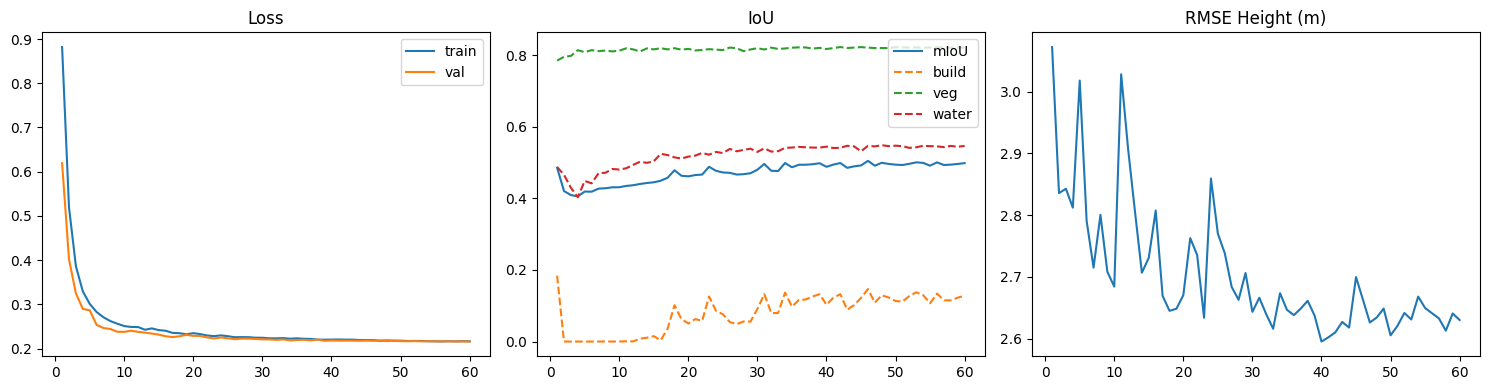

 epoch      trn      val     miou    iou_b    iou_v    iou_w   rmse_h
    56 0.216405 0.216402 0.500601 0.134205 0.822207 0.545390 2.641046
    57 0.216695 0.216659 0.493252 0.115104 0.821474 0.543177 2.632781
    58 0.216543 0.216301 0.494321 0.115141 0.821215 0.546606 2.612808
    59 0.216897 0.216334 0.496131 0.122728 0.821385 0.544279 2.640635
    60 0.216707 0.216057 0.498609 0.128018 0.821337 0.546472 2.630028


In [ ]:
# ── 8. Training curves ────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import pandas as pd

df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(df.epoch, df.trn, label='train')
axes[0].plot(df.epoch, df.val, label='val')
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(df.epoch, df.miou,  label='mIoU')
axes[1].plot(df.epoch, df.iou_b, label='build', linestyle='--')
axes[1].plot(df.epoch, df.iou_v, label='veg',   linestyle='--')
axes[1].plot(df.epoch, df.iou_w, label='water', linestyle='--')
axes[1].set_title('IoU'); axes[1].legend()

axes[2].plot(df.epoch, df.rmse_h)
axes[2].set_title('RMSE Height (m)')

plt.tight_layout(); plt.show()
print(df.tail(5).to_string(index=False))

In [ ]:
# ── 9. Copy test files to local SSD ──────────────────────────────────────────
LOCAL_TEST = Path('/content/test_ae')
LOCAL_TEST.mkdir(exist_ok=True)

test_files = sorted(AE_TEST.glob('*.tif'))
print(f'Copying {len(test_files)} test files to SSD…')
for p in test_files:
    dst = LOCAL_TEST / p.name
    if not dst.exists():
        safe_copy(p, dst)
print(f'Done. Local test files: {len(sorted(LOCAL_TEST.glob("*.tif")))}')

Copying 946 test files to SSD…
Done. Local test files: 946


In [ ]:
# ── 10. Inference & submission ────────────────────────────────────────────────
import zipfile

model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

SUB_PRED = Path('/content/predictions')
SUB_PRED.mkdir(exist_ok=True)

test_files = sorted(LOCAL_TEST.glob('*.tif'))
print(f'Inference on {len(test_files)} patches…')

for p in test_files:
    ae = load_tif(p)                                       # (64, 256, 256)
    ae = (ae - AE_MEAN) / AE_STD
    ae = np.nan_to_num(ae, nan=0.0)
    ae_t = torch.from_numpy(ae).unsqueeze(0).to(DEVICE)   # (1, 64, 256, 256)

    with torch.no_grad(), torch.amp.autocast('cuda'):
        seg_logits, h_p = model(ae_t)

    seg_np = torch.sigmoid(seg_logits).squeeze(0).float().cpu().numpy()  # (3, 256, 256)
    h_np   = torch.expm1(h_p).clamp(0).squeeze(0).float().cpu().numpy() # metres
    pred   = np.concatenate([seg_np, h_np], axis=0).astype(np.float32)  # (4, 256, 256)

    # emb_3942_OG_2023_quantized.tif → 3942_OG_2023.npy
    clean = re.sub(r'^emb_', '', p.stem)
    clean = re.sub(r'_quantized$', '', clean)
    np.save(SUB_PRED / f'{clean}.npy', pred)

n_saved = len(sorted(SUB_PRED.glob('*.npy')))
print(f'Saved {n_saved} prediction files.')

SUB_ZIP = DRIVE_ROOT / 'submission_ae_only.zip'
with zipfile.ZipFile(SUB_ZIP, 'w', zipfile.ZIP_DEFLATED) as zf:
    for npy in sorted(SUB_PRED.glob('*.npy')):
        zf.write(npy, f'predictions/{npy.name}')
print(f'Zip saved: {SUB_ZIP}  ({SUB_ZIP.stat().st_size/1e6:.1f} MB)')

Inference on 946 patches…
Saved 946 prediction files.
Zip saved: /content/drive/MyDrive/ESA_Challenge/submission_ae_only.zip  (493.1 MB)


In [ ]:
# ── 11. Sanity check ──────────────────────────────────────────────────────────
import zipfile
with zipfile.ZipFile(SUB_ZIP) as zf:
    names = zf.namelist()
    print(f'Files in zip: {len(names)}')
    arr = np.load(zf.open(names[0]))
    print(f'Shape : {arr.shape}')          # (4, 256, 256)
    print(f'Build : {arr[0].min():.3f} – {arr[0].max():.3f}')
    print(f'Veg   : {arr[1].min():.3f} – {arr[1].max():.3f}')
    print(f'Water : {arr[2].min():.3f} – {arr[2].max():.3f}')
    print(f'Height: {arr[3].min():.1f}m – {arr[3].max():.1f}m')

Files in zip: 946
Shape : (4, 256, 256)
Build : 0.000 – 0.625
Veg   : 0.000 – 1.000
Water : 0.000 – 0.495
Height: 0.0m – 21.9m
